## Objetivo: Predecir supervivientes del titanic

### Replicar el clasificador del Kagle del 
[link](https://www.kaggle.com/code/sociopath00/random-forest-using-gridsearchcv/notebook)

In [1]:
# usamos los datos de titanic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importamos scikit learn

from sklearn.model_selection import train_test_split #Split
from sklearn.model_selection import cross_val_score #cross validation
from sklearn.model_selection import GridSearchCV #grid search
from sklearn.ensemble import RandomForestClassifier #RF clasificador
from sklearn.metrics import accuracy_score #metricas de error
from sklearn.svm import SVC #
from scipy.stats import chi2_contingency #Para colinearidad entre categoricas

In [2]:
#Cargamos el archivo

titanic = pd.read_csv("Data/titanic.csv")
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
#Analisis exploratorio

#Sexo

distr_sexo = titanic.groupby('Sex', as_index=False).size().rename({'size':'Cantidad'}, axis=1)

distr_sexo['%'] = ((distr_sexo['Cantidad']/distr_sexo['Cantidad'].sum())*100).round(2)

distr_sexo



,Sex,Cantidad,%
0,female,314,35.24
1,male,577,64.76


In [4]:
#Sobrevivientes

sobrev = titanic.groupby('Survived', as_index=False).size().rename({'size':'Cantidad'}, axis=1)
sobrev['%'] = ((sobrev['Cantidad']/sobrev['Cantidad'].sum())*100).round(2)
sobrev

,Survived,Cantidad,%
0,0,549,61.62
1,1,342,38.38


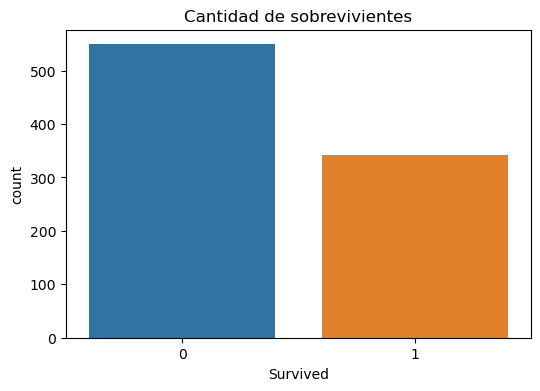

In [5]:
#graficamos los sobreviviente con seaborn

fig , ax = plt.subplots(figsize=(6,4))
sns.countplot(x='Survived', data=titanic)
plt.title("Cantidad de sobrevivientes")
plt.show()

In [6]:
#Reviso las variables de nuevo

titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#veo la matriz de correlacion de variables

#Identificamos las variables entre numéricas y categoricas

cat=['Sex','Embarked']
num=['Age','SibSp','Parch','Fare','Pclass']
cat
num

['Age', 'SibSp', 'Parch', 'Fare', 'Pclass']

In [8]:
corr_df=titanic[num]  #New dataframe to calculate correlation between numeric features
cor= corr_df.corr(method='pearson')
print(cor)

             Age     SibSp     Parch      Fare    Pclass
Age     1.000000 -0.308247 -0.189119  0.096067 -0.369226
SibSp  -0.308247  1.000000  0.414838  0.159651  0.083081
Parch  -0.189119  0.414838  1.000000  0.216225  0.018443
Fare    0.096067  0.159651  0.216225  1.000000 -0.549500
Pclass -0.369226  0.083081  0.018443 -0.549500  1.000000


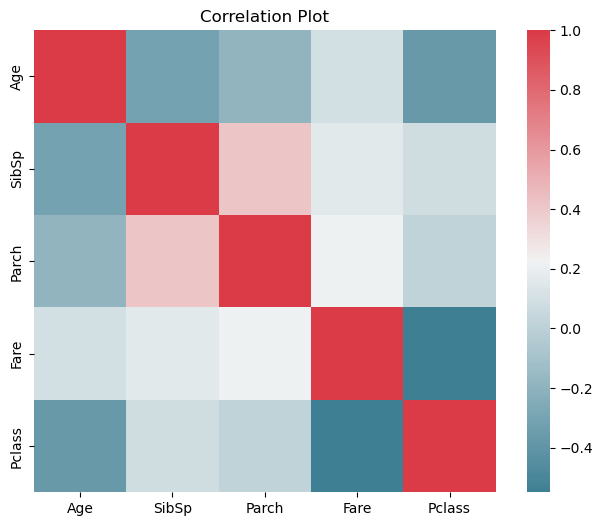

In [9]:
#Matriz de correlacion

fig, ax =plt.subplots(figsize=(8, 6))
plt.title("Correlation Plot")
sns.heatmap(cor, mask=np.zeros_like(cor, dtype=np.bool_), cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)
plt.show()

In [11]:
#Vemos colinearidad entre las variables categoricas
#usamos chi-cuadrado

csq= chi2_contingency(pd.crosstab(titanic['Survived'], titanic['Sex']))
#print("P-value: ",csq[1])

csq

(260.71702016732104,
 1.1973570627755645e-58,
 1,
 array([[193.47474747, 355.52525253],
        [120.52525253, 221.47474747]]))